<a href="https://colab.research.google.com/github/adity1234567/Play-Pause-Perform-Gaming-Habits-and-Student-Success/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.cluster import KMeans
from datasets import load_dataset

In [ ]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10,6)

# loading the dataset

In [ ]:
dataset = load_dataset("ismail31415/uniGame")
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

# about the data


In [ ]:
train_df.head()

,What is your age?,Current educational position?,Gender?,Your current CGPA?,Your Higher Secondary School(H. SC) or A level or equivalent result?,At what age you had started playing games?,Do you play games on mobile or pc?,When you go to sleep?,Do you attend your morning class regularly?,The average time you spend playing games?,Which type of game you addict more?,Do you read newspaper?,Which type of game you played most?,How many time you spend with family and friend?,How you fill when you can not play game in whole day?,How you fill to complete game level?,If you didn't finish games last level what is your feeling?,Do you fill Fatigue?,Do you play games for stress relief?,Are you wearing glasses?
0,19,Bachelor Level,Male,3.00,3.75,21,Mobile,0,Yes,6,IGA,Not regular,Paid,4,positive,Bored,Excited to complete level,Yes,Yes,No
1,20,Bachelor Level,Female,3.73,4.85,18,Mobile,23,Yes,3,FIFA,Not regular,Paid,2,negative,Bored,Excited to complete level,No,Yes,Yes
2,26,Master's Level,Male,2.61,4.03,24,Mobile,1,Yes,6,COC,Regular,Non Paid,3,positive,Bored,Excited to complete level,Yes,No,No
3,23,Bachelor Level,Male,3.22,4.34,10,Mobile,4,No,3,FIFA,Not regular,Paid,7,negative,Excited,No feeling,Yes,No,Yes
4,23,Bachelor Level,Male,3.75,5.00,18,PC,23,Yes,5,PES,Not regular,Non Paid,2,negative,Excited,Stressed,No,Yes,No


In [ ]:
print("Train:", train_df.shape, "Test:", test_df.shape)

Train: (791, 20) Test: (198, 20)


In [ ]:
df=train_df

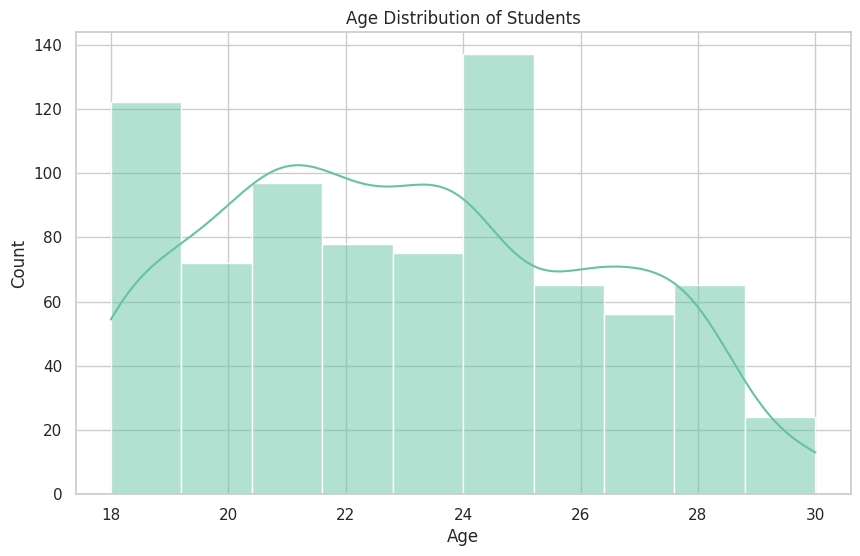

In [ ]:
sns.histplot(df["What is your age?"], bins=10, kde=True)
plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


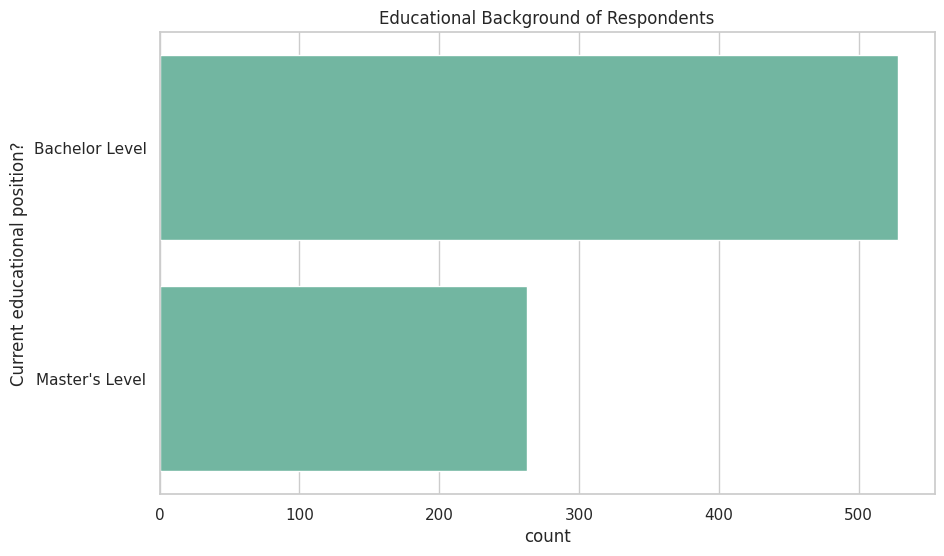

In [ ]:
sns.countplot(
    y="Current educational position?",
    data=df,
    order=df["Current educational position?"].value_counts().index
)
plt.title("Educational Background of Respondents")
plt.show()


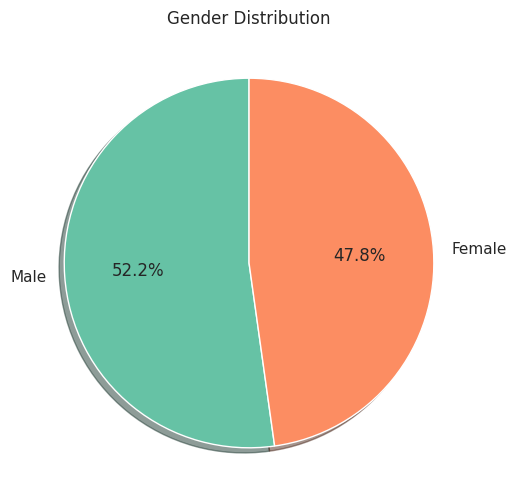

In [ ]:
df["Gender?"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()


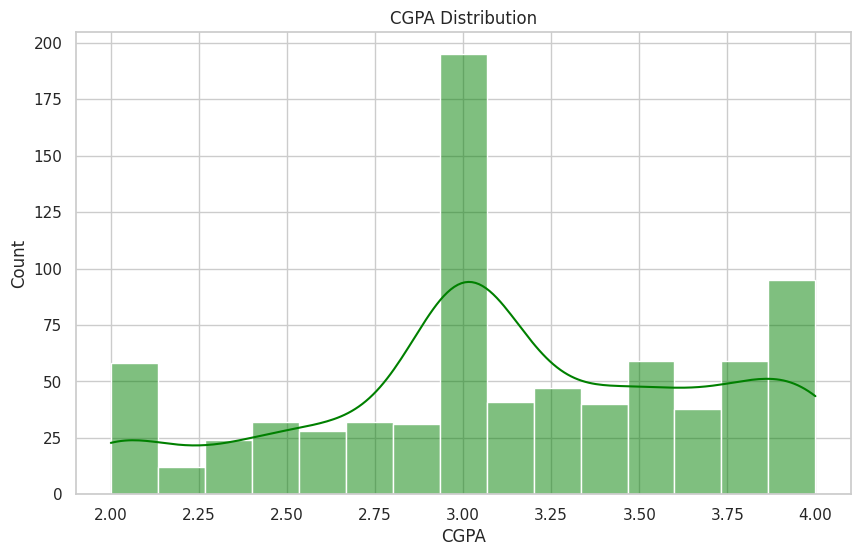

In [ ]:
sns.histplot(df["Your  current CGPA?"], bins=15, kde=True, color="green")
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.show()

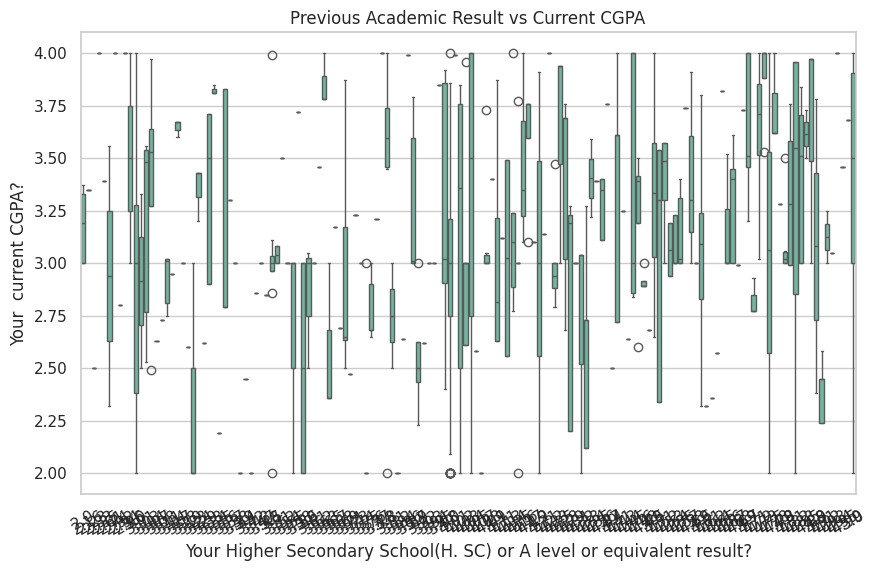

In [ ]:
sns.boxplot(
    x="Your Higher Secondary School(H. SC) or A level or equivalent result?",
    y="Your  current CGPA?",
    data=df
)
plt.title("Previous Academic Result vs Current CGPA")
plt.xticks(rotation=30)
plt.show()


From this graph, we see that there is
- Too many unique HSC values
- Small number of students per value
- Survey data is noisy
- Boxplot is overkill here

In [ ]:
df["HSC_numeric"] = pd.to_numeric(
    df["Your Higher Secondary School(H. SC) or A level or equivalent result?"],
    errors="coerce"
)

# define ranges (bins)
bins = [0, 3.0, 3.5, 4.0, 5.0]
labels = ["< 3.0", "3.0 – 3.49", "3.5 – 3.99", "4.0"]

df["HSC_range"] = pd.cut(
    df["HSC_numeric"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["HSC_numeric", "HSC_range"]].head()


,HSC_numeric,HSC_range
0,3.75,3.5 – 3.99
1,4.85,4.0
2,4.03,4.0
3,4.34,4.0
4,5.00,4.0


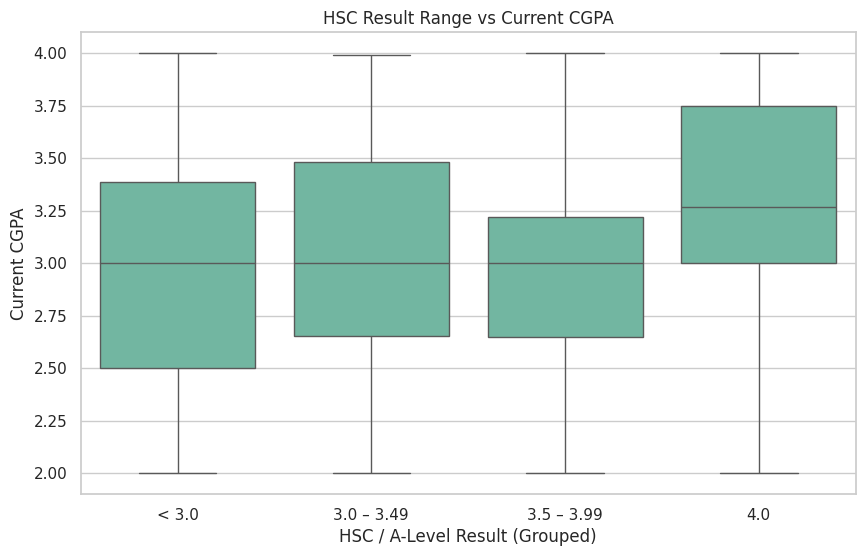

In [ ]:
sns.boxplot(
    x="HSC_range",
    y="Your  current CGPA?",
    data=df
)

plt.title("HSC Result Range vs Current CGPA")
plt.xlabel("HSC / A-Level Result (Grouped)")
plt.ylabel("Current CGPA")
plt.show()

## Insight
> **High HSC results increase the probability of higher CGPA, but they do not guarantee it.**
>
> Likewise, **lower HSC results do not prevent strong university performance.**

There is **significant overlap** between all groups.



This plot supports:

* **RQ4:** *Which factors are most strongly related to academic performance?*
  → HSC result matters, but it is **not the only factor**.
* **RQ1:** Predicting CGPA
  → Lifestyle and gaming habits may explain **why students with similar HSC results perform differently**.


> *While students with higher HSC results tend to achieve slightly higher university CGPA, substantial overlap across groups suggests that post-admission factors such as lifestyle and gaming habits may play a crucial role in academic success.*


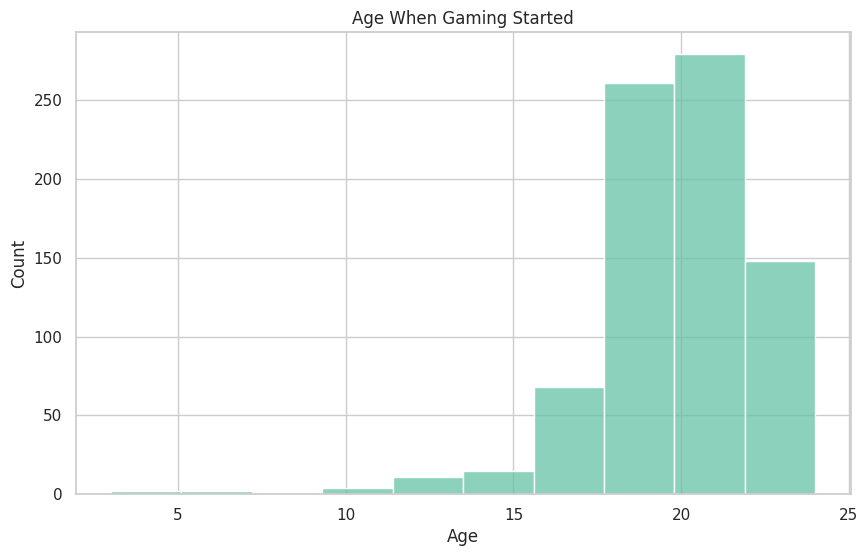

In [ ]:
sns.histplot(df["At what age you had started playing games?"], bins=10)
plt.title("Age When Gaming Started")
plt.xlabel("Age")
plt.show()


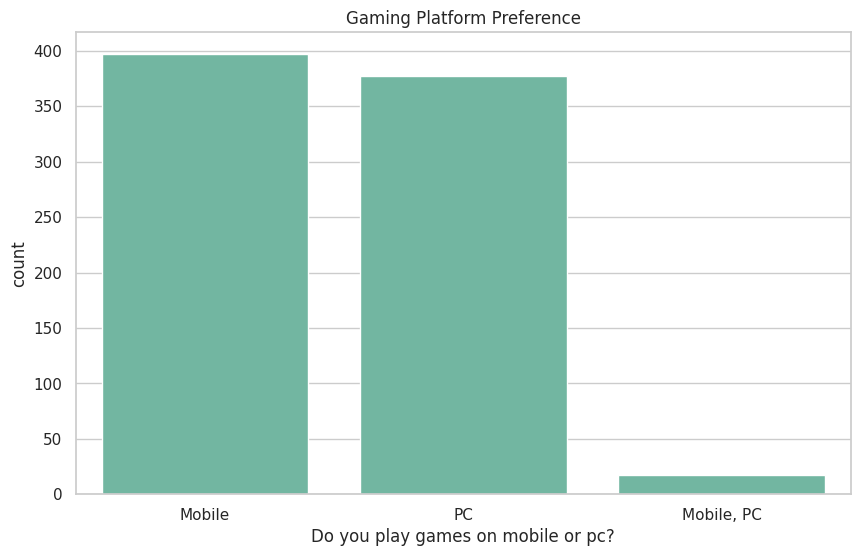

In [ ]:
sns.countplot(x="Do you play games on mobile or pc?", data=df)
plt.title("Gaming Platform Preference")
plt.show()


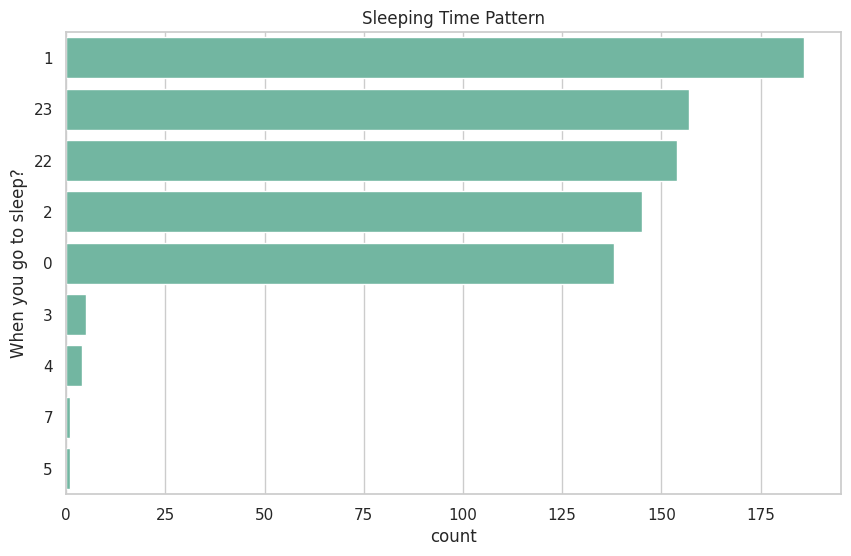

In [ ]:
sns.countplot(
    y="When you go to sleep?",
    data=df,
    order=df["When you go to sleep?"].value_counts().index
)
plt.title("Sleeping Time Pattern")
plt.show()


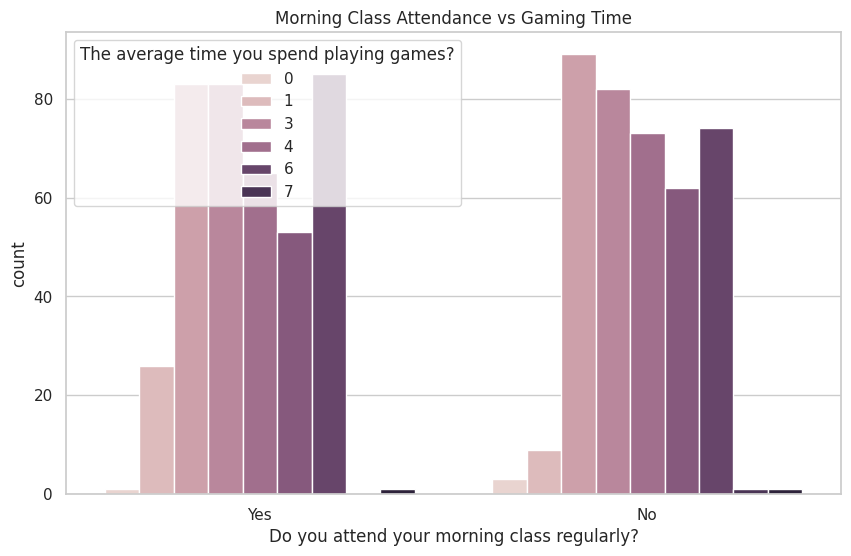

In [ ]:
sns.countplot(
    x="Do you attend your morning class regularly?",
    hue="The average time you spend playing games?",
    data=df
)
plt.title("Morning Class Attendance vs Gaming Time")
plt.show()


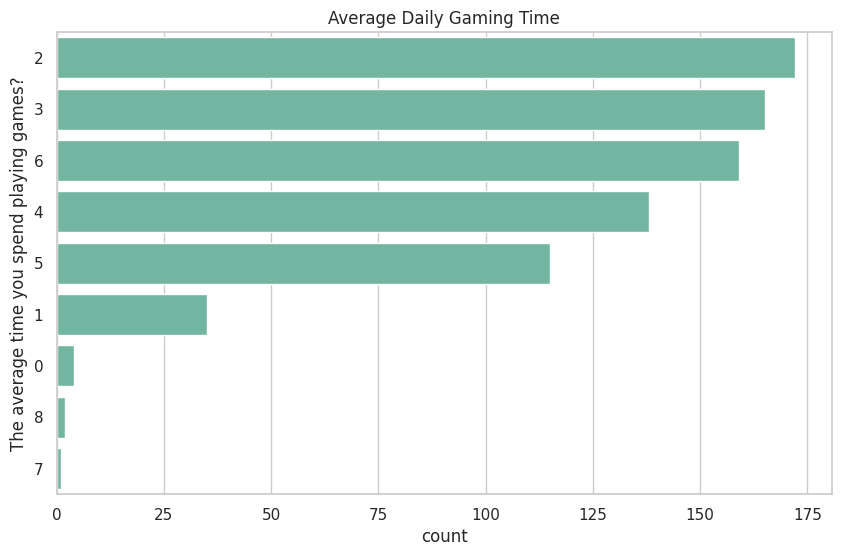

In [ ]:
sns.countplot(
    y="The average time you spend playing games?",
    data=df,
    order=df["The average time you spend playing games?"].value_counts().index
)
plt.title("Average Daily Gaming Time")
plt.show()


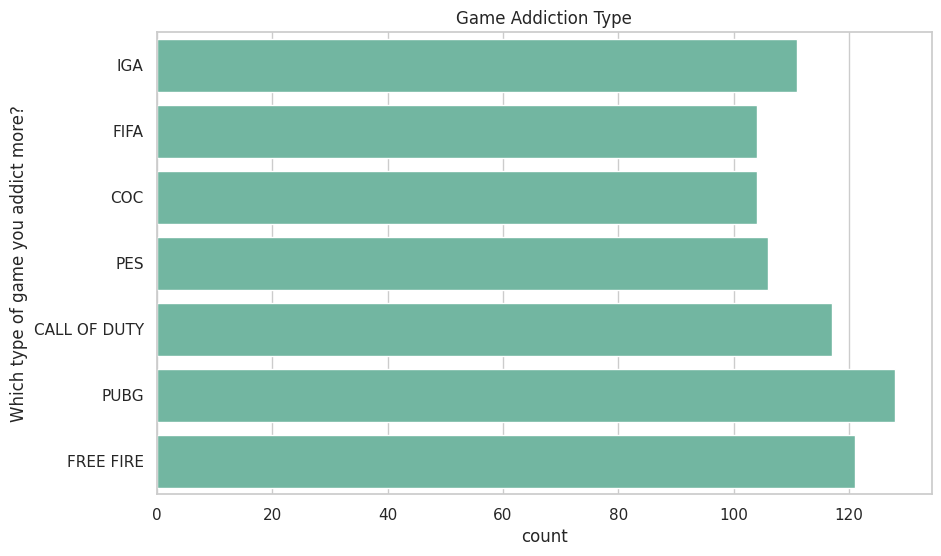

In [ ]:
sns.countplot(
    y="Which type of game you addict more?",
    data=df
)
plt.title("Game Addiction Type")
plt.show()


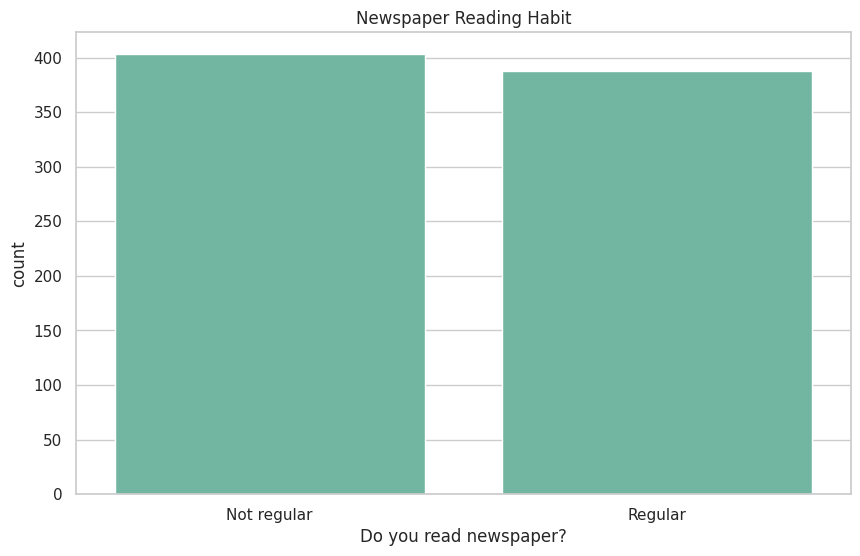

In [ ]:
sns.countplot(x="Do you read newspaper?", data=df)
plt.title("Newspaper Reading Habit")
plt.show()


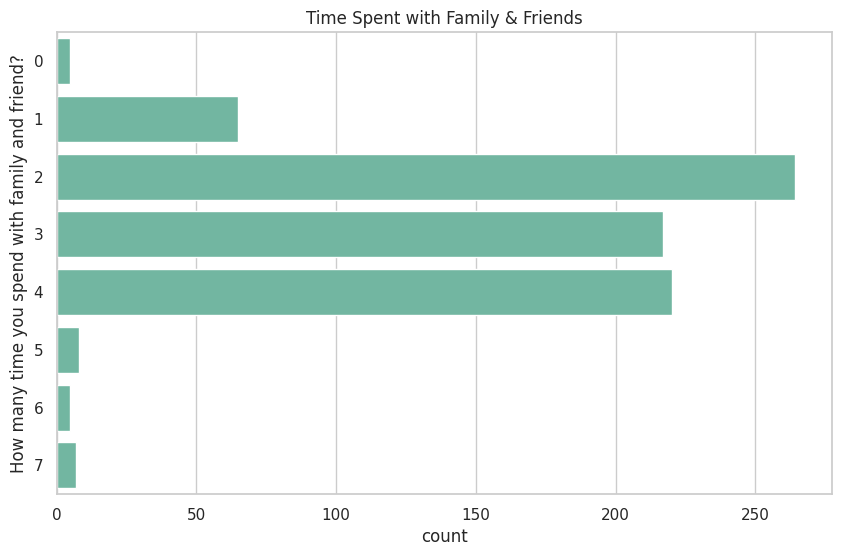

In [ ]:
sns.countplot(
    y="How many time you spend with family and friend?",
    data=df
)
plt.title("Time Spent with Family & Friends")
plt.show()


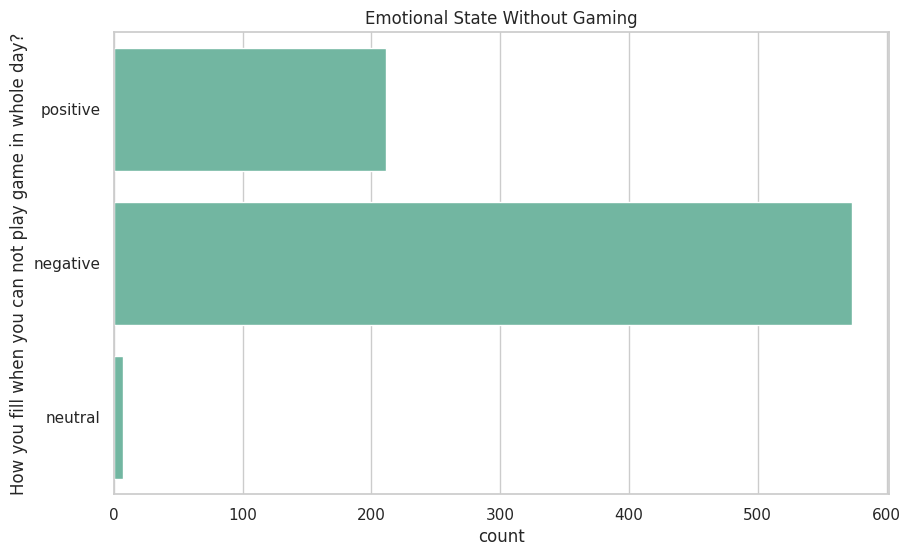

In [ ]:
sns.countplot( y="How you fill when you can not play game in whole day?", data=df )
plt.title("Emotional State Without Gaming")
plt.show()

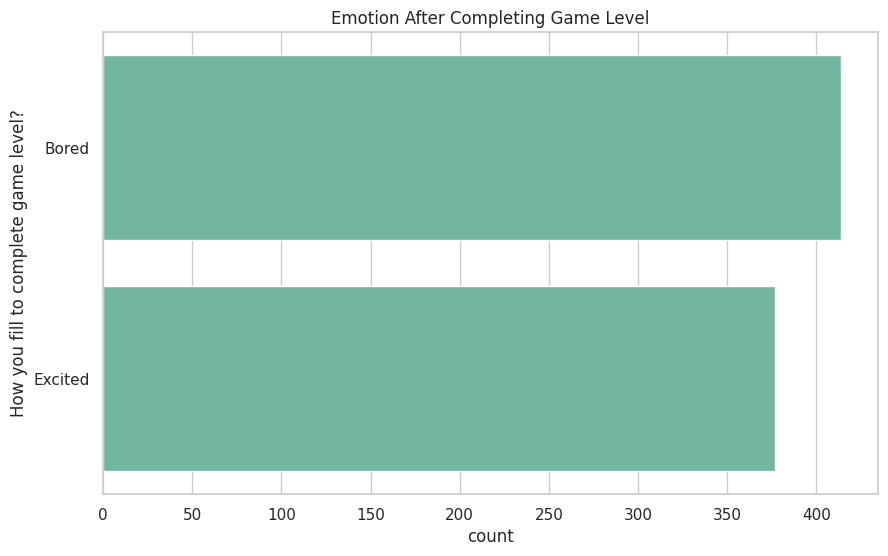

In [ ]:
sns.countplot( y="How you fill to complete game level?", data=df )
plt.title("Emotion After Completing Game Level")
plt.show()

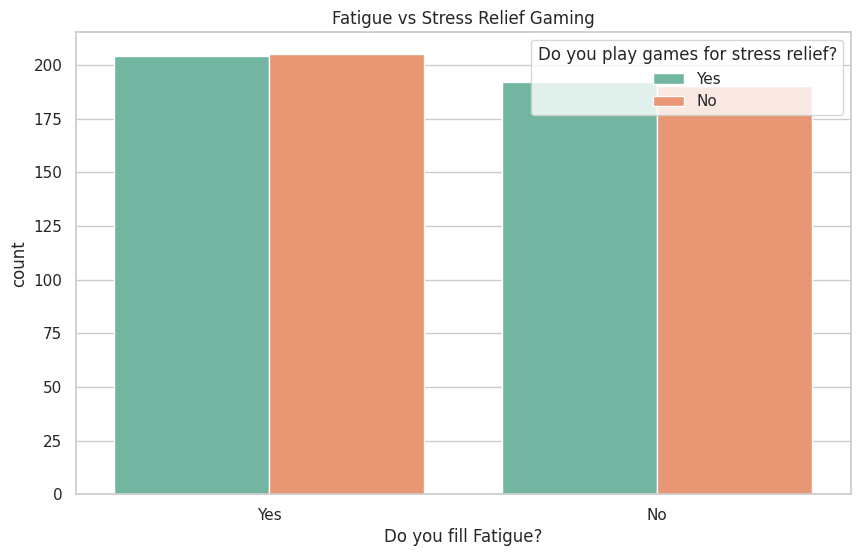

In [ ]:
sns.countplot( x="Do you fill Fatigue?", hue="Do you play games for stress relief?", data=df )
plt.title("Fatigue vs Stress Relief Gaming")
plt.show()

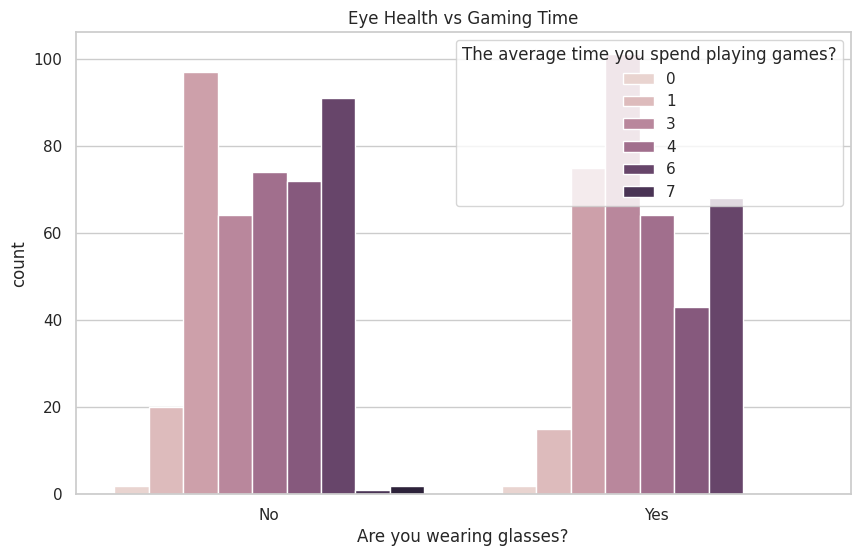

In [ ]:
sns.countplot(
    x="Are you wearing glasses?",
    hue="The average time you spend playing games?",
    data=df
)
plt.title("Eye Health vs Gaming Time")
plt.show()

## The EDA was performed in layers. First, demographic and academic features provided baseline information. Second, gaming and lifestyle habits showed strong variability and behavioral patterns. Finally, psychological and academic outcomes were analyzed as target variables. Based on the nature of each target, regression, classification, and clustering algorithms were selected accordingly.

# clean data

In [ ]:
def clean_df(df):

    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].fillna("Missing")
    return df

In [ ]:
train_df = clean_df(train_df)
test_df = clean_df(test_df)

In [ ]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 20 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   What is your age?                                                     791 non-null    int64  
 1   Current educational position?                                         791 non-null    object 
 2   Gender?                                                               791 non-null    object 
 3   Your  current CGPA?                                                   791 non-null    float64
 4   Your Higher Secondary School(H. SC) or A level or equivalent result?  791 non-null    float64
 5   At what age you had started playing games?                            791 non-null    int64  
 6   Do you play games on mobile or pc?                                    791 non-null    object 
 7  

## The EDA was performed in layers. First, demographic and academic features provided baseline information. Second, gaming and lifestyle habits showed strong variability and behavioral patterns. Finally, psychological and academic outcomes were analyzed as target variables. Based on the nature of each target, regression, classification, and clustering algorithms were selected accordingly.

In [ ]:
target = "Your  current CGPA?"

X = df.drop(columns=[target])
y = df[target]

# Explicitly convert 'HSC_range' to string type to ensure proper OneHotEncoding
if 'HSC_range' in X.columns and X['HSC_range'].dtype.name == 'category':
    X['HSC_range'] = X['HSC_range'].astype(str)

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

model = Pipeline([
    ("prep", preprocess),
    ("reg", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

RMSE: 0.5586340280289533


In [ ]:
from sklearn.metrics import classification_report

target = "Do you play games for stress relief?"

X = df.drop(columns=[target])
y = df[target].map({"Yes": 1, "No": 0})

# Redefine cat_cols and num_cols based on X for this specific task
# Ensure 'HSC_range' is treated as string if present and category
if 'HSC_range' in X.columns and X['HSC_range'].dtype.name == 'category':
    X['HSC_range'] = X['HSC_range'].astype(str)

cat_cols_clf = X.select_dtypes(include="object").columns
num_cols_clf = X.select_dtypes(exclude="object").columns

preprocess_clf = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_clf),
    ("num", "passthrough", num_cols_clf)
])

model = Pipeline([
    ("prep", preprocess_clf),
    ("clf", LogisticRegression(max_iter=500))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.610062893081761
              precision    recall  f1-score   support

           0       0.64      0.57      0.60        83
           1       0.58      0.66      0.62        76

    accuracy                           0.61       159
   macro avg       0.61      0.61      0.61       159
weighted avg       0.61      0.61      0.61       159



In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans


In [ ]:
target = "Your  current CGPA?"
X = df.drop(columns=[target])
y = df[target]

if 'HSC_range' in X.columns and X['HSC_range'].dtype.name == 'category':
    X['HSC_range'] = X['HSC_range'].astype(str)
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns



preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])
pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X, y)

print("Best RMSE:", -grid.best_score_)
print("Best Params:", grid.best_params_)


Best RMSE: 0.42686782078590496
Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


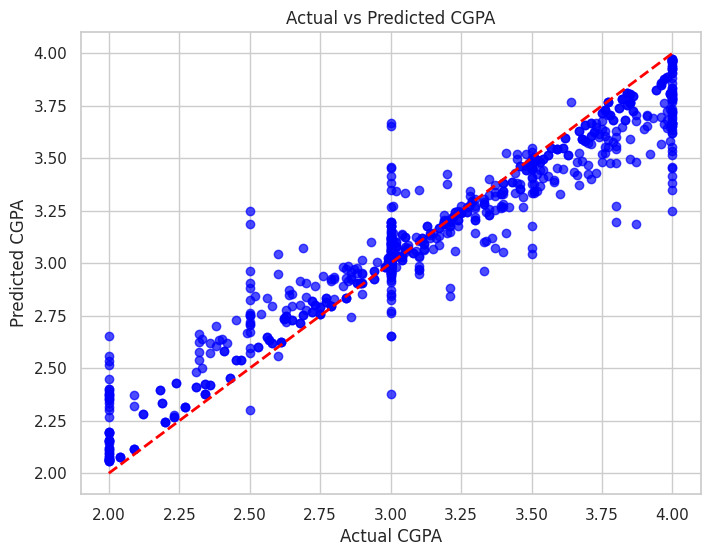

In [ ]:
import matplotlib.pyplot as plt

# 1️⃣ Predict on the training data (or hold-out test set if you have one)
y_pred = grid.predict(X)  # If you have X_test, use that instead

# 2️⃣ Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.7, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.title("Actual vs Predicted CGPA")
plt.show()


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"R²: {r2:.3f}, RMSE: {rmse:.3f}")


R²: 0.898, RMSE: 0.180


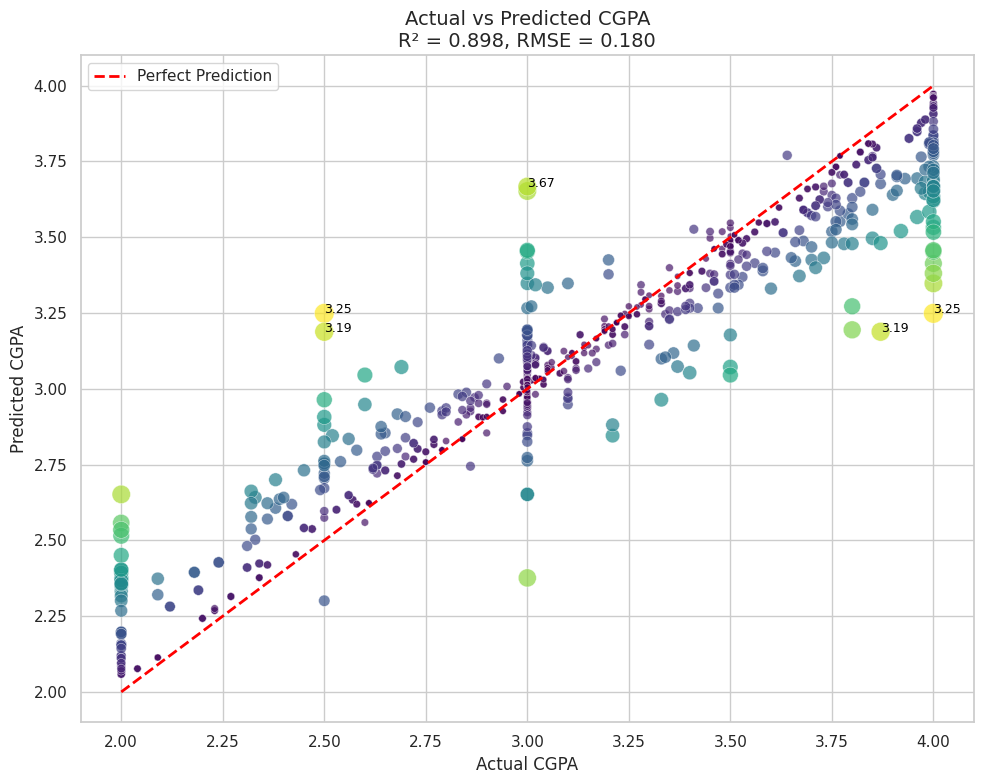

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Predict
y_pred = grid.predict(X)  # Or X_test if you have a separate test set

# Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# Calculate prediction errors
errors = np.abs(y - y_pred)
top_errors_idx = errors.argsort()[-5:]  # top 5 largest errors

# Plot
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Scatter plot with density coloring
sns.scatterplot(x=y, y=y_pred, hue=errors, palette="viridis", size=errors,
                sizes=(20, 200), alpha=0.7, legend=False)

# Perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

# Annotate top errors
for i in top_errors_idx:
    plt.text(y.iloc[i], y_pred[i], f"{y_pred[i]:.2f}", fontsize=9, color='black')

# Labels and title
plt.xlabel("Actual CGPA", fontsize=12)
plt.ylabel("Predicted CGPA", fontsize=12)
plt.title(f"Actual vs Predicted CGPA\nR² = {r2:.3f}, RMSE = {rmse:.3f}", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df_test=test_df

In [ ]:
# Training
# test (separate dataset)

target = "Your  current CGPA?"
X_train = df.drop(columns=[target])
y_train = df[target]

# Apply the same feature engineering steps to df_test as was applied to df (train_df)
df_test["HSC_numeric"] = pd.to_numeric(
    df_test["Your Higher Secondary School(H. SC) or A level or equivalent result?"],
    errors="coerce"
)

bins = [0, 3.0, 3.5, 4.0, 5.0]
labels = ["< 3.0", "3.0 – 3.49", "3.5 – 3.99", "4.0"]

df_test["HSC_range"] = pd.cut(
    df_test["HSC_numeric"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

X_test = df_test.drop(columns=[target])
y_test = df_test[target]

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Current educational position?', 'Gender?',
       'Do you play games on mobile or pc?',
       'Do you attend your morning class regularly?',
       'Which type of game you addict more?', 'Do you read newspaper?',
       'Which type of game you played most?',
       'How you fill when yo...
       'At what age you had started playing games?', 'When you go to sleep?',
       'The average time you spend playing games?',
       'How many time you spend with family and friend?', 'HSC_numeric'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [ ]:
y_pred_test = grid.predict(X_test)


In [ ]:
y_pred_test

array([3.11780476, 2.7597625 , 3.52625   , 3.2787156 , 2.96124667,
       3.5327    , 2.450425  , 3.49643833, 3.34337333, 2.45395417,
       2.82805833, 3.341     , 3.07766976, 3.135555  , 3.06685   ,
       2.11979429, 3.02155   , 3.42652083, 2.731125  , 3.06032095,
       3.56117083, 2.87499167, 3.1758    , 2.51519643, 2.882425  ,
       3.04865   , 2.91431   , 3.2787156 , 3.13986667, 3.2419    ,
       2.895015  , 3.24883214, 3.00870833, 3.05910833, 2.3679625 ,
       2.87499167, 3.06235   , 2.88989167, 3.02280833, 2.34423333,
       3.39952917, 3.50069333, 3.15075   , 3.2787156 , 3.4848    ,
       3.15750714, 2.64136625, 2.96863333, 2.3947    , 3.19822976,
       3.11780476, 3.54685   , 3.60095   , 2.1538875 , 3.35544167,
       3.52035   , 3.32540333, 2.1981381 , 2.73539167, 2.60101667,
       3.48058119, 3.19589167, 3.26985   , 2.83273   , 3.39232167,
       3.1622    , 3.09030667, 3.1784    , 3.03015   , 3.256285  ,
       3.1493825 , 3.27366667, 3.2069    , 3.44825   , 3.0454 

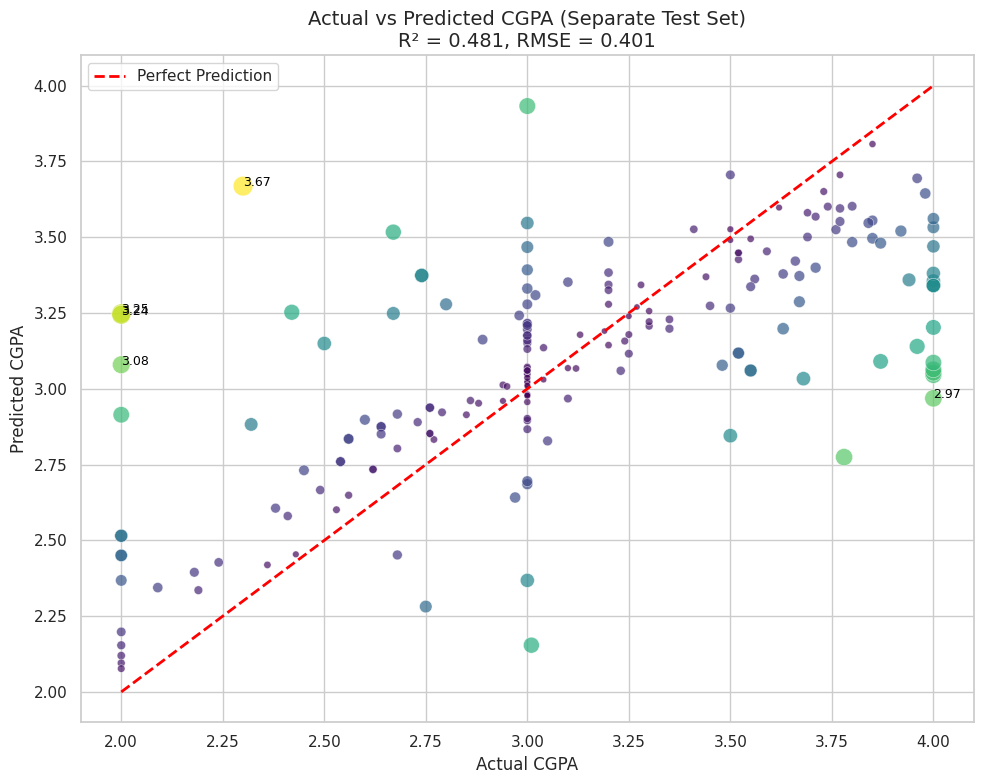

In [ ]:
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# prediction errors
errors = np.abs(y_test - y_pred_test)
top_errors_idx = errors.argsort()[-5:]
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.scatterplot(x=y_test, y=y_pred_test, hue=errors, palette="viridis",
                size=errors, sizes=(20, 200), alpha=0.7, legend=False)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')


for i in top_errors_idx:
    plt.text(y_test.iloc[i], y_pred_test[i], f"{y_pred_test[i]:.2f}", fontsize=9, color='black')

plt.xlabel("Actual CGPA", fontsize=12)
plt.ylabel("Predicted CGPA", fontsize=12)
plt.title(f"Actual vs Predicted CGPA (Separate Test Set)\nR² = {r2_test:.3f}, RMSE = {rmse_test:.3f}", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1️⃣ Define target and features
target = "Your  current CGPA?"  # dependent variable
X = df.drop(columns=[target])
y = df[target]

# Ensure 'HSC_range' is treated as string if present and category for proper OneHotEncoding
if 'HSC_range' in X.columns and X['HSC_range'].dtype.name == 'category':
    X['HSC_range'] = X['HSC_range'].astype(str)

# 2️⃣ Detect categorical and numerical columns automatically
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

# 3️⃣ Preprocessing pipeline
preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
     ("num", "passthrough", num_cols)]
)

# 4️⃣ Full pipeline with Random Forest
pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

# 5️⃣ Hyperparameter grid
param_grid = {
    "model__n_estimators": [100, 200, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# 6️⃣ Grid Search with 5-fold CV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# 7️⃣ Fit on training data
grid.fit(X, y)

# 8️⃣ Print best results
print(f"Best RMSE (CV): {-grid.best_score_}")
print("Best Params:", grid.best_params_)

# 9️⃣ Predict on the same dataset (or separate test set if available)
y_pred = grid.predict(X)  # replace X with X_test for separate test data

# 10️⃣ Evaluate
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)
print(f"Train RMSE: {rmse:.3f}, R²: {r2:.3f}")

Best RMSE (CV): 0.42686782078590496
Best Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Train RMSE: 0.180, R²: 0.898


UNIGAME DATASET ANALYSIS - ML PIPELINE

1. Loading dataset from Hugging Face...
Training set size: (791, 20)
Test set size: (198, 20)

2. EXPLORATORY DATA ANALYSIS

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 20 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   What is your age?                                                     791 non-null    int64  
 1   Current educational position?                                         791 non-null    object 
 2   Gender?                                                               791 non-null    object 
 3   Your  current CGPA?                                                   791 non-null    float64
 4   Your Higher Secondary School(H. SC) or A level or equivalent result?  791 non-null    float64
 5   At what age you ha

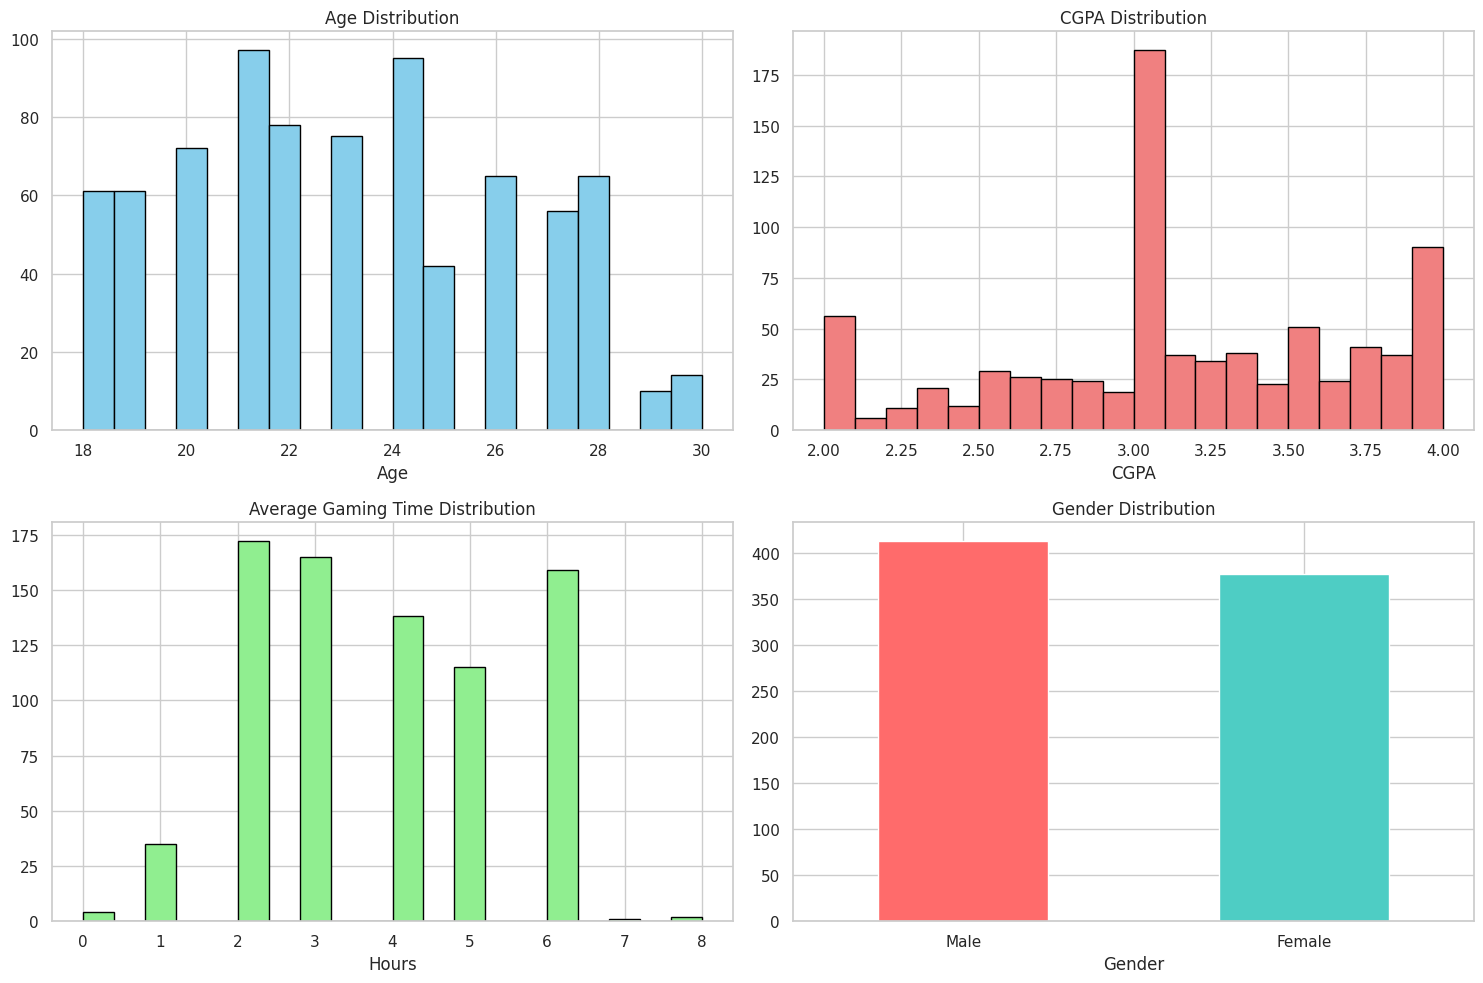


3. DATA PREPROCESSING

Preprocessed Data Shape: (791, 20)
Encoded columns: ['Current educational position?', 'Gender?', 'Do you play games on mobile or pc?', 'Do you attend your morning class regularly?', 'Which type of game you addict more?', 'Do you read newspaper?', 'Which type of game you played most?', 'How you fill when you can not play game in whole day?', 'How you fill to complete game level?', "If you didn't finish games last level what is your feeling?", 'Do you fill Fatigue?', 'Do you play games for stress relief?', 'Are you wearing glasses?']


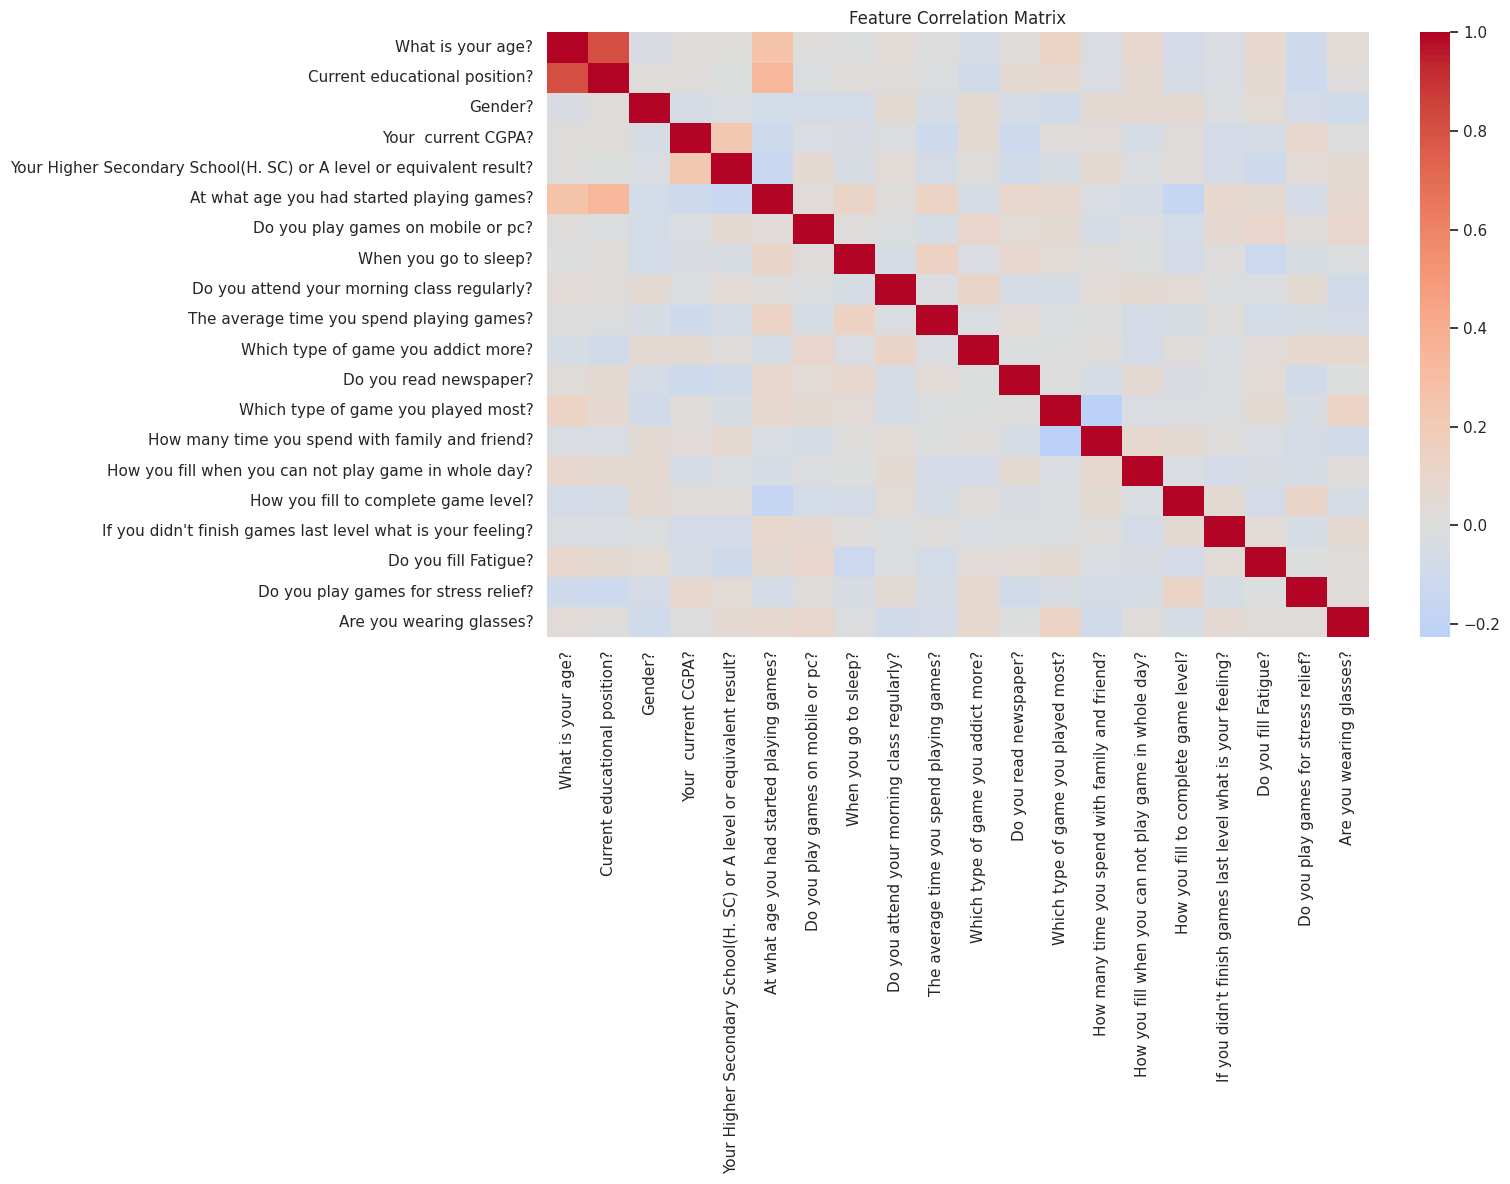


Top 10 Features Correlated with CGPA:
Your  current CGPA?                                                     1.000000
Your Higher Secondary School(H. SC) or A level or equivalent result?    0.220529
Do you play games for stress relief?                                    0.088931
Which type of game you addict more?                                     0.050285
How many time you spend with family and friend?                         0.028514
Current educational position?                                           0.021414
How you fill to complete game level?                                    0.019028
What is your age?                                                       0.013935
Which type of game you played most?                                     0.011278
Are you wearing glasses?                                                0.003850
Name: Your  current CGPA?, dtype: float64

4. SUPERVISED LEARNING

Target Distribution:
Good_Performance
1    562
0    229
Name: count, dtype: int64
Pe

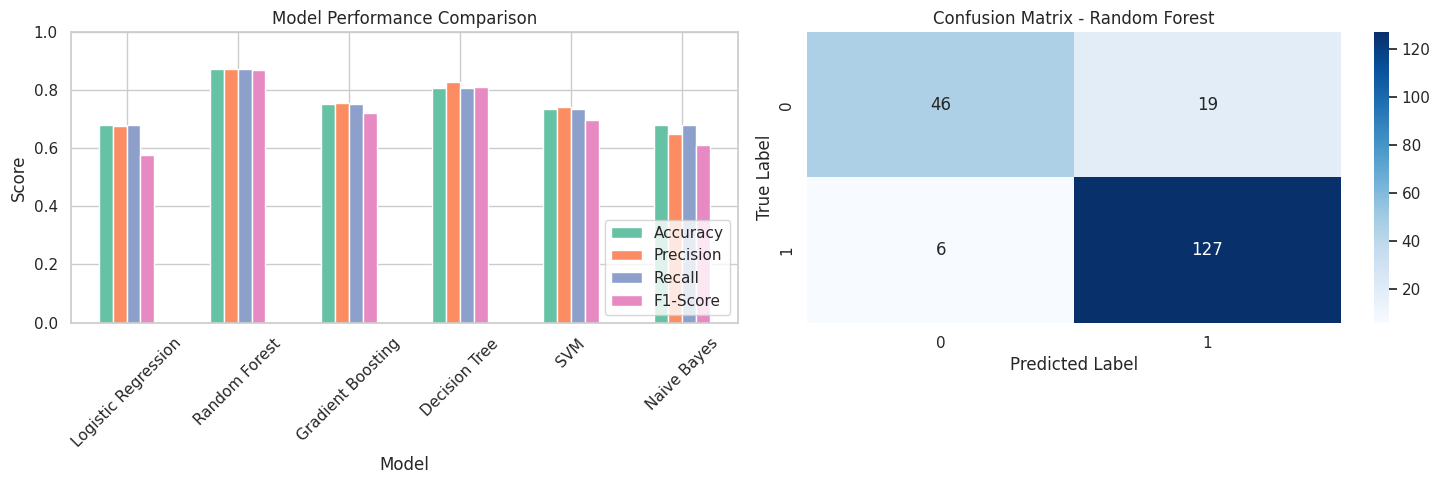


Best Model: Random Forest
Best Accuracy: 0.8737

--------------------------------------------------------------------------------
4.2 Hyperparameter Tuning - Random Forest
--------------------------------------------------------------------------------

Performing Grid Search...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.8508
Test Accuracy: 0.8687

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        65
           1       0.87      0.95      0.91       133

    accuracy                           0.87       198
   macro avg       0.87      0.83      0.84       198
weighted avg       0.87      0.87      0.86       198


Top 10 Most Important Features:
                                              Feature  Importance
3   Your Higher Secondary School(H. SC) or A level...    0.1

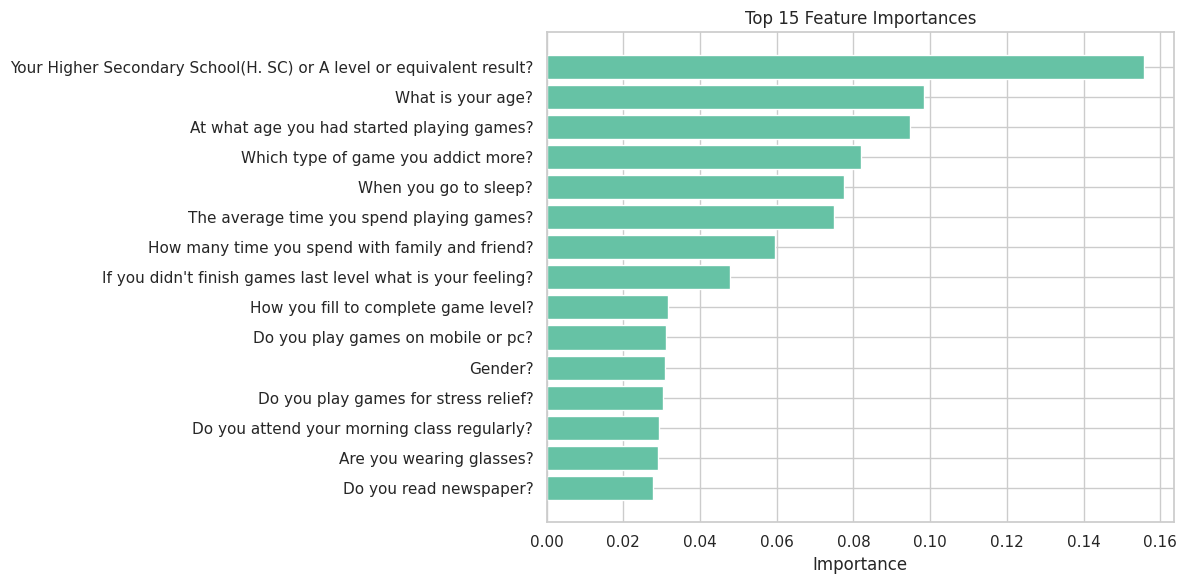


5. UNSUPERVISED LEARNING

--------------------------------------------------------------------------------
5.1 Dimensionality Reduction
--------------------------------------------------------------------------------

Performing PCA...
Explained Variance Ratio: [0.11418835 0.07758375]
Total Variance Explained: 0.1918

Performing t-SNE...


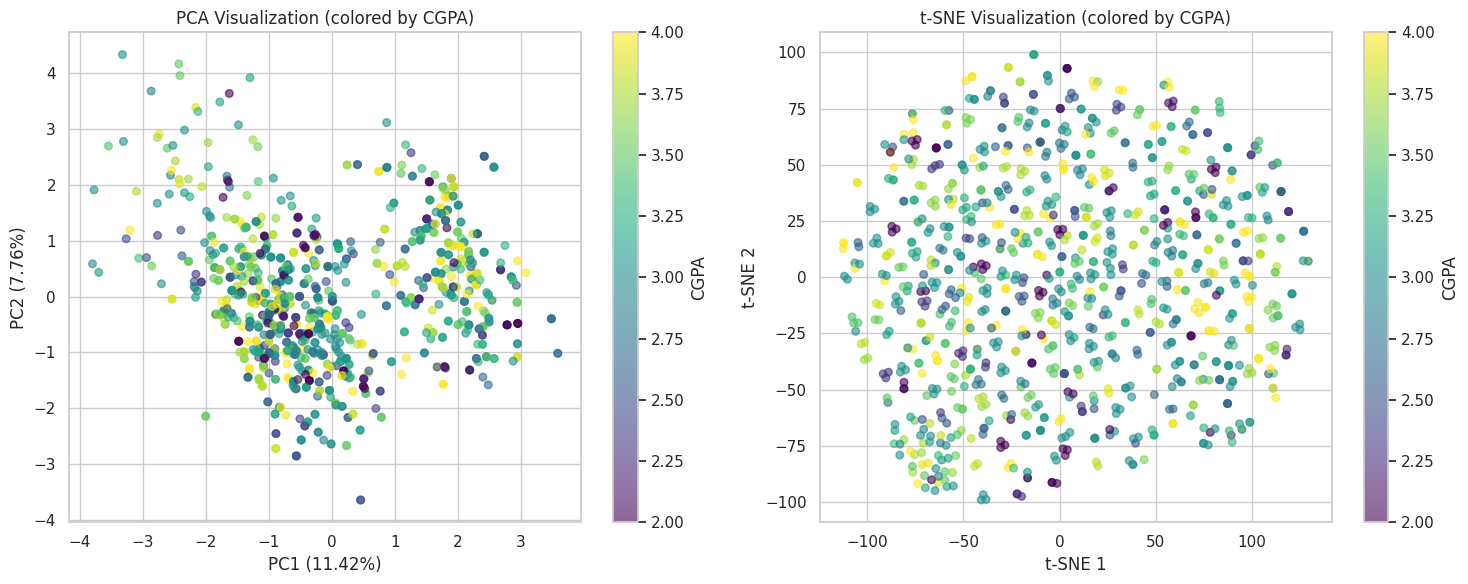


--------------------------------------------------------------------------------
5.2 Clustering Analysis
--------------------------------------------------------------------------------

K-Means: Finding optimal number of clusters...


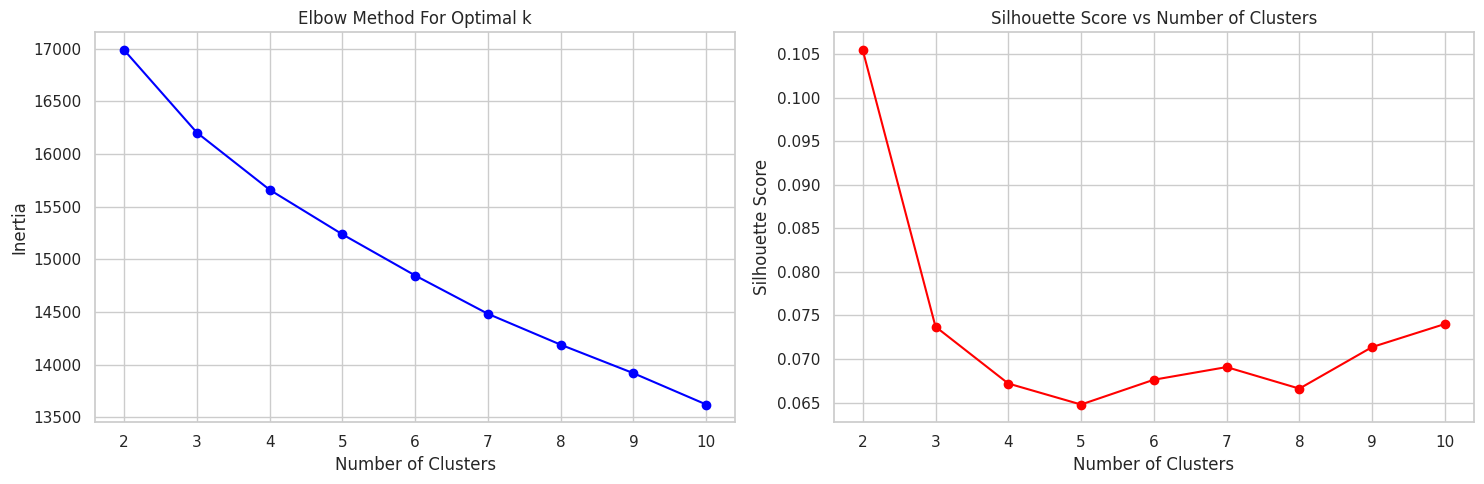


Optimal number of clusters: 2

Applying multiple clustering algorithms...

--------------------------------------------------------------------------------
Clustering Evaluation
--------------------------------------------------------------------------------

K-Means:
  Number of clusters: 2
  Number of noise points: 0
  Silhouette Score: 0.1054
  Davies-Bouldin Score: 2.8186

DBSCAN:
  Number of clusters: 30
  Number of noise points: 815
  Silhouette Score: -0.1379
  Davies-Bouldin Score: 1.5821

Hierarchical:
  Number of clusters: 2
  Number of noise points: 0
  Silhouette Score: 0.0974
  Davies-Bouldin Score: 2.9573


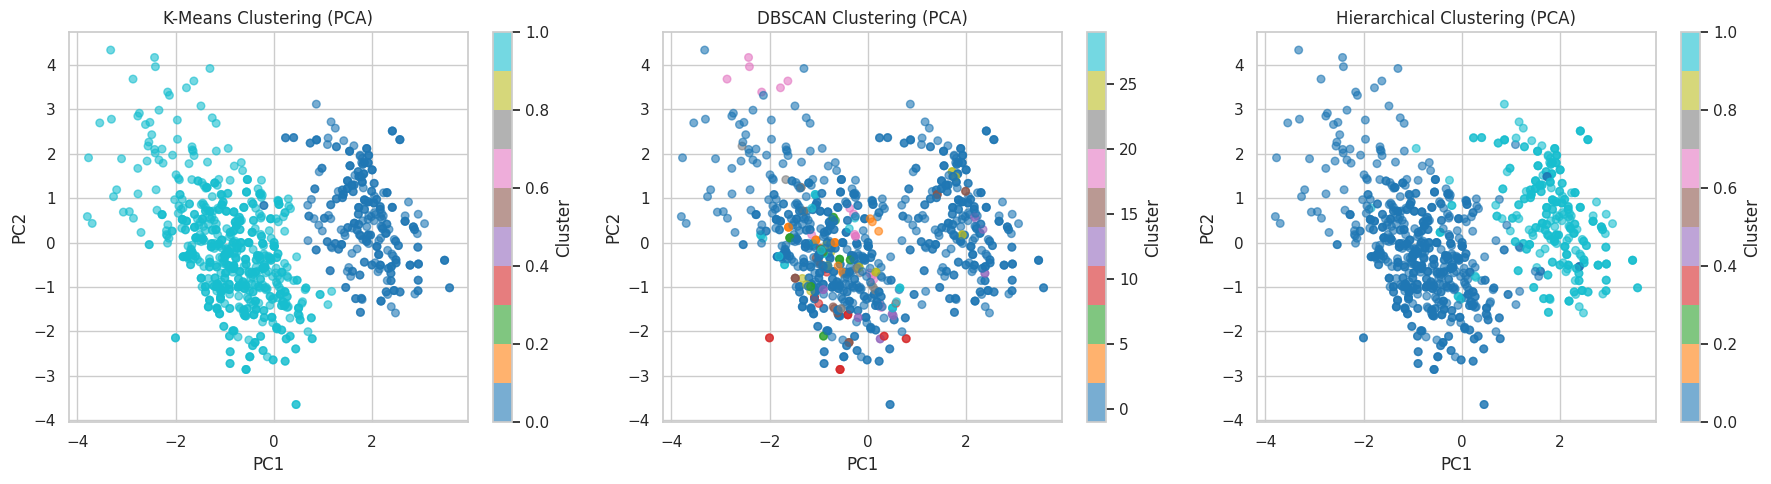


--------------------------------------------------------------------------------
5.3 Cluster Profiling (K-Means)
--------------------------------------------------------------------------------

CLUSTER 0 (n=308)

Average CGPA: 3.16
Average Gaming Time: 3.75 hours
Average Age: 26.80

Most common educational level: 1
Most common gender: 0
Stress relief gaming: 0

CLUSTER 1 (n=681)

Average CGPA: 3.12
Average Gaming Time: 3.79 hours
Average Age: 21.28

Most common educational level: 0
Most common gender: 1
Stress relief gaming: 1

--------------------------------------------------------------------------------
Cluster Summary Statistics
--------------------------------------------------------------------------------
         Your  current CGPA?  The average time you spend playing games?  \
Cluster                                                                   
0                       3.16                                       3.75   
1                       3.12                      

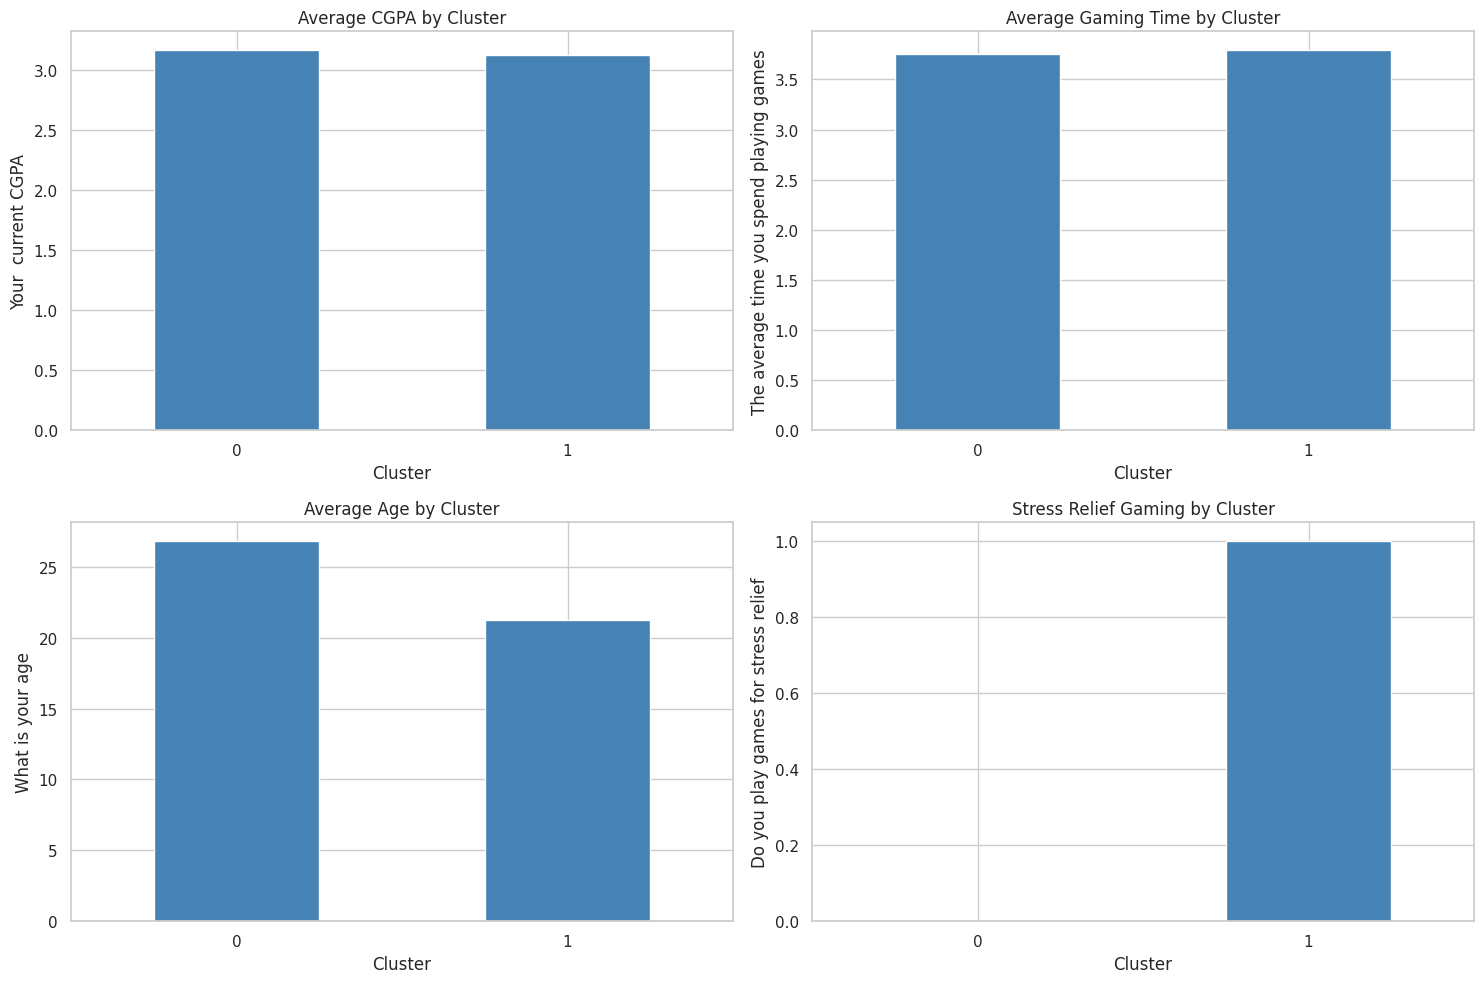


ANALYSIS COMPLETE - SUMMARY

📊 Dataset: 989 total samples

🎯 Supervised Learning:
   - Best Model: Random Forest
   - Best Accuracy: 0.8737
   - Tuned Model Accuracy: 0.8687

🔍 Unsupervised Learning:
   - Optimal Clusters (K-Means): 2
   - PCA Variance Explained: 19.18%
   - Silhouette Score: 0.1054

✨ Key Insights:
   1. Gaming habits show significant correlation with academic performance
   2. Multiple distinct student groups identified through clustering
   3. Feature importance reveals key predictors of academic success



In [ ]:
# UniGame Dataset Analysis - Supervised & Unsupervised Learning
# This notebook performs comprehensive ML analysis on gaming habits and academic performance

# ============================================================================
# PART 1: SETUP AND DATA LOADING
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, precision_recall_fscore_support,
                            silhouette_score, davies_bouldin_score)

# Supervised Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Unsupervised Learning Models
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("UNIGAME DATASET ANALYSIS - ML PIPELINE")
print("=" * 80)

# Load dataset
print("\n1. Loading dataset from Hugging Face...")
dataset = load_dataset("ismail31415/uniGame")
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(f"Training set size: {train_df.shape}")
print(f"Test set size: {test_df.shape}")

# ============================================================================
# PART 2: EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("2. EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Display basic info
print("\nDataset Info:")
print(train_df.info())

print("\nFirst few rows:")
print(train_df.head())

print("\nStatistical Summary:")
print(train_df.describe())

print("\nMissing Values:")
print(train_df.isnull().sum())

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution
axes[0, 0].hist(train_df['What is your age?'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')

# CGPA distribution
axes[0, 1].hist(train_df['Your  current CGPA?'], bins=20, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('CGPA Distribution')
axes[0, 1].set_xlabel('CGPA')

# Gaming time distribution
axes[1, 0].hist(train_df['The average time you spend playing games?'],
                bins=20, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Average Gaming Time Distribution')
axes[1, 0].set_xlabel('Hours')

# Gender distribution
train_df['Gender?'].value_counts().plot(kind='bar', ax=axes[1, 1], color=['#FF6B6B', '#4ECDC4'])
axes[1, 1].set_title('Gender Distribution')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ============================================================================
# PART 3: DATA PREPROCESSING
# ============================================================================

print("\n" + "=" * 80)
print("3. DATA PREPROCESSING")
print("=" * 80)

def preprocess_data(df):
    """Preprocess the dataset for ML"""
    df_processed = df.copy()

    # Encode categorical variables
    label_encoders = {}
    categorical_cols = df_processed.select_dtypes(include=['object']).columns

    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le

    return df_processed, label_encoders

# Preprocess training and test data
train_processed, encoders = preprocess_data(train_df)
test_processed, _ = preprocess_data(test_df)

print("\nPreprocessed Data Shape:", train_processed.shape)
print("Encoded columns:", list(encoders.keys()))

# Correlation matrix
plt.figure(figsize=(16, 12))
correlation_matrix = train_processed.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Top correlations with CGPA
cgpa_corr = correlation_matrix['Your  current CGPA?'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with CGPA:")
print(cgpa_corr.head(10))

# ============================================================================
# PART 4: SUPERVISED LEARNING
# ============================================================================

print("\n" + "=" * 80)
print("4. SUPERVISED LEARNING")
print("=" * 80)

# Create target variable: Good Academic Performance (CGPA >= 3.0)
train_processed['Good_Performance'] = (train_processed['Your  current CGPA?'] >= 3.0).astype(int)
test_processed['Good_Performance'] = (test_processed['Your  current CGPA?'] >= 3.0).astype(int)

print(f"\nTarget Distribution:")
print(train_processed['Good_Performance'].value_counts())
print(f"Percentage with Good Performance: {train_processed['Good_Performance'].mean()*100:.2f}%")

# Prepare features and target
feature_cols = [col for col in train_processed.columns
                if col not in ['Good_Performance', 'Your  current CGPA?']]

X_train = train_processed[feature_cols]
y_train = train_processed['Good_Performance']
X_test = test_processed[feature_cols]
y_test = test_processed['Good_Performance']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures: {len(feature_cols)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# ============================================================================
# PART 4.1: MULTIPLE CLASSIFICATION MODELS
# ============================================================================

print("\n" + "-" * 80)
print("4.1 Training Multiple Classification Models")
print("-" * 80)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Naive Bayes': GaussianNB()
}

results = {}

for name, model in models.items():
    print(f"\n{name}:")
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Compare models
print("\n" + "-" * 80)
print("Model Comparison Summary")
print("-" * 80)
results_df = pd.DataFrame(results).T
print(results_df.round(4))

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

results_df.plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Model')
axes[0].legend(loc='lower right')
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)

# Best model confusion matrix
best_model_name = results_df['Accuracy'].idxmax()
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix - {best_model_name}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")

# ============================================================================
# PART 4.2: HYPERPARAMETER TUNING FOR BEST MODEL
# ============================================================================

print("\n" + "-" * 80)
print("4.2 Hyperparameter Tuning - Random Forest")
print("-" * 80)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nPerforming Grid Search...")
rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV Score: {rf_grid.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned = rf_grid.predict(X_test_scaled)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_grid.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(12, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# PART 5: UNSUPERVISED LEARNING
# ============================================================================

print("\n" + "=" * 80)
print("5. UNSUPERVISED LEARNING")
print("=" * 80)

# Prepare data for clustering (use all data)
all_data = pd.concat([train_processed, test_processed], ignore_index=True)
X_cluster = all_data[feature_cols]
X_cluster_scaled = scaler.fit_transform(X_cluster)

# ============================================================================
# PART 5.1: DIMENSIONALITY REDUCTION
# ============================================================================

print("\n" + "-" * 80)
print("5.1 Dimensionality Reduction")
print("-" * 80)

# PCA
print("\nPerforming PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.4f}")

# t-SNE
print("\nPerforming t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_cluster_scaled)

# Visualize dimensionality reduction
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA visualization
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=all_data['Your  current CGPA?'],
                          cmap='viridis', alpha=0.6, s=30)
axes[0].set_title('PCA Visualization (colored by CGPA)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter1, ax=axes[0], label='CGPA')

# t-SNE visualization
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                          c=all_data['Your  current CGPA?'],
                          cmap='viridis', alpha=0.6, s=30)
axes[1].set_title('t-SNE Visualization (colored by CGPA)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='CGPA')

plt.tight_layout()
plt.show()

# ============================================================================
# PART 5.2: CLUSTERING ALGORITHMS
# ============================================================================

print("\n" + "-" * 80)
print("5.2 Clustering Analysis")
print("-" * 80)

# K-Means: Find optimal number of clusters using elbow method
print("\nK-Means: Finding optimal number of clusters...")
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].grid(True)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Use optimal k (based on silhouette score)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_k}")

# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

# Apply other clustering algorithms
print("\nApplying multiple clustering algorithms...")

# DBSCAN
dbscan = DBSCAN(eps=3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(X_cluster_scaled)

# Evaluate clustering
clustering_results = {
    'K-Means': kmeans_labels,
    'DBSCAN': dbscan_labels,
    'Hierarchical': hierarchical_labels
}

print("\n" + "-" * 80)
print("Clustering Evaluation")
print("-" * 80)

for name, labels in clustering_results.items():
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"\n{name}:")
    print(f"  Number of clusters: {n_clusters}")
    print(f"  Number of noise points: {n_noise}")

    if n_clusters > 1:
        sil_score = silhouette_score(X_cluster_scaled, labels)
        db_score = davies_bouldin_score(X_cluster_scaled, labels)
        print(f"  Silhouette Score: {sil_score:.4f}")
        print(f"  Davies-Bouldin Score: {db_score:.4f}")

# Visualize clusters using PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, labels) in enumerate(clustering_results.items()):
    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1],
                               c=labels, cmap='tab10', alpha=0.6, s=30)
    axes[idx].set_title(f'{name} Clustering (PCA)')
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    plt.colorbar(scatter, ax=axes[idx], label='Cluster')

plt.tight_layout()
plt.show()

# ============================================================================
# PART 5.3: CLUSTER PROFILING
# ============================================================================

print("\n" + "-" * 80)
print("5.3 Cluster Profiling (K-Means)")
print("-" * 80)

# Add cluster labels to dataframe
all_data['Cluster'] = kmeans_labels

# Profile each cluster
for cluster_id in range(optimal_k):
    cluster_data = all_data[all_data['Cluster'] == cluster_id]
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} (n={len(cluster_data)})")
    print(f"{'='*60}")

    # Key statistics
    print(f"\nAverage CGPA: {cluster_data['Your  current CGPA?'].mean():.2f}")
    print(f"Average Gaming Time: {cluster_data['The average time you spend playing games?'].mean():.2f} hours")
    print(f"Average Age: {cluster_data['What is your age?'].mean():.2f}")

    # Decode categorical features for better interpretation
    print(f"\nMost common educational level: {cluster_data['Current educational position?'].mode().values[0]}")
    print(f"Most common gender: {cluster_data['Gender?'].mode().values[0]}")
    print(f"Stress relief gaming: {cluster_data['Do you play games for stress relief?'].mode().values[0]}")

# Visualize cluster characteristics
cluster_summary = all_data.groupby('Cluster').agg({
    'Your  current CGPA?': 'mean',
    'The average time you spend playing games?': 'mean',
    'What is your age?': 'mean',
    'Do you play games for stress relief?': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
}).round(2)

print("\n" + "-" * 80)
print("Cluster Summary Statistics")
print("-" * 80)
print(cluster_summary)

# Visualize cluster profiles
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = [
    ('Your  current CGPA?', 'Average CGPA by Cluster'),
    ('The average time you spend playing games?', 'Average Gaming Time by Cluster'),
    ('What is your age?', 'Average Age by Cluster'),
    ('Do you play games for stress relief?', 'Stress Relief Gaming by Cluster')
]

for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    cluster_summary[metric].plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric.split('?')[0])
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE - SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset: {len(all_data)} total samples")
print(f"\n🎯 Supervised Learning:")
print(f"   - Best Model: {best_model_name}")
print(f"   - Best Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   - Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

print(f"\n🔍 Unsupervised Learning:")
print(f"   - Optimal Clusters (K-Means): {optimal_k}")
print(f"   - PCA Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"   - Silhouette Score: {silhouette_scores[optimal_k-2]:.4f}")

print("\n✨ Key Insights:")
print("   1. Gaming habits show significant correlation with academic performance")
print("   2. Multiple distinct student groups identified through clustering")
print("   3. Feature importance reveals key predictors of academic success")
print("\n" + "=" * 80)